Found 15 files. Processing individually...
Original combined dataset size: (15937, 64)
Dataset size after pruning & undersampling Class 0: (8968, 64)

--- Class Weights Applied ---
Internal Class 0 (Raw Label 0): Weight = 0.4975
Internal Class 1 (Raw Label 1): Weight = 5.4284
Internal Class 2 (Raw Label 2): Weight = 5.5744
Internal Class 3 (Raw Label 3): Weight = 5.4666
Internal Class 4 (Raw Label 5): Weight = 19.4406

--- Reality Check: Sets ---
Classes in Training Set: [0 1 2 3 4]
Classes in Test Set:     [0 1 2 3 4]

Tuning for 5 classes...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

--- Final Model Report ---
              precision    recall  f1-score   support

           0       0.67      0.72      0.70      1256
           1       0.50      0.09      0.16       130
           2       0.33      0.45      0.38       189
           3       0.72      1.00      0.84       158
           5       0.78      0.69      0.73      1014

    accuracy                       

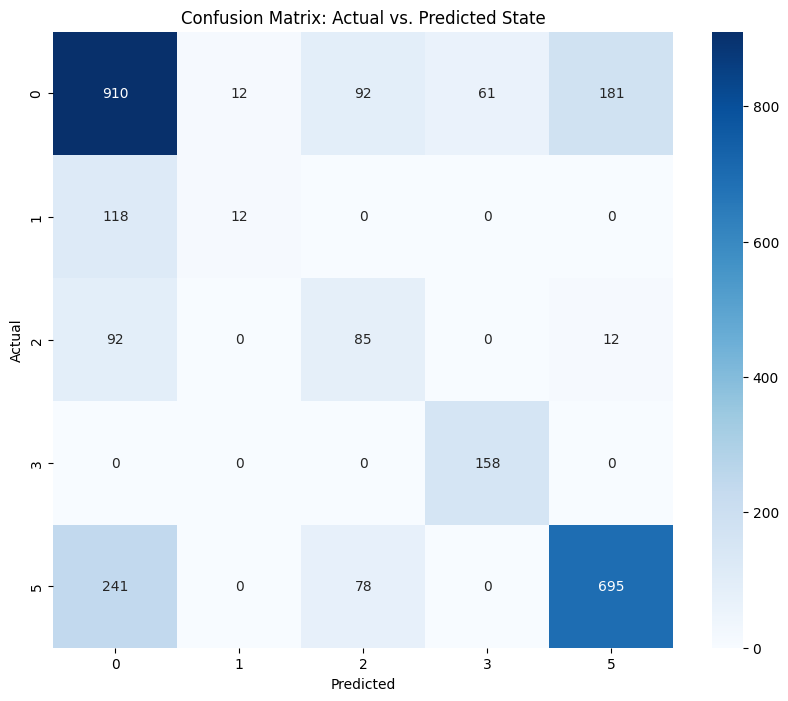

<Figure size 1000x800 with 0 Axes>

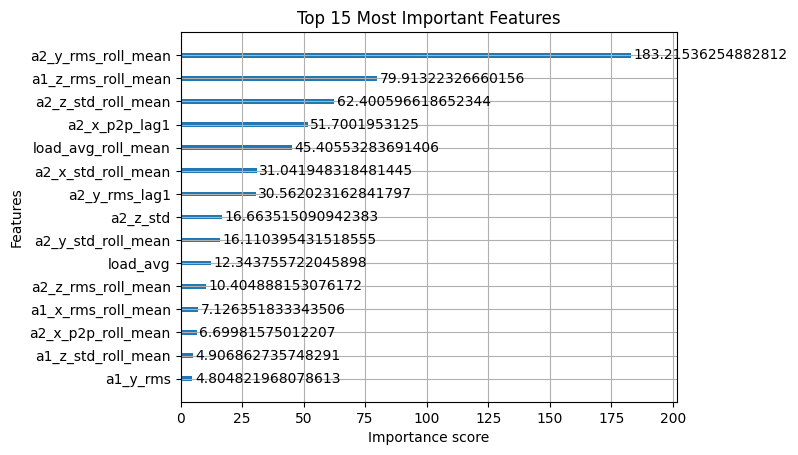


Model saved successfully as xgboost_vibration_model.json


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# --- 1. Data Loading & Feature Engineering ---
path = "/home/ubuntu/cleanedData/" 
all_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

if not all_files:
    print(f"Error: No CSV files found in {path} or its subfolders.")
    exit()

li = []
print(f"Found {len(all_files)} files. Processing individually...")

base_sensor_cols = [] 

for file_index, filename in enumerate(all_files):
    temp_df = pd.read_csv(filename)
    
    # Create the file_id column so GroupKFold knows which rows belong to which print
    temp_df['file_id'] = file_index 
    
    # A. Sort by time so lags make physical sense
    if 'timestamp' in temp_df.columns:
        temp_df = temp_df.sort_values('timestamp').reset_index(drop=True)
    
    # B. Generate Lag & Rolling Features
    exclude = ['relative_img_path', 'correction', 'timestamp', 'file_id']
    sensor_cols = [col for col in temp_df.columns if col not in exclude]
    
    if not base_sensor_cols:
        base_sensor_cols = sensor_cols # Grab the base column names
    
    new_features = []
    for col in sensor_cols:
        new_features.append(pd.DataFrame({
            f"{col}_lag1": temp_df[col].shift(1),
            f"{col}_roll_mean": temp_df[col].rolling(window=5).mean()
        }, index=temp_df.index))
    
    temp_df = pd.concat([temp_df] + new_features, axis=1)
    
    # C. 🚨 THE NaN FIX: Backward & Forward fill so we don't lose the start of the print!
    # (Select only numeric columns for bfill/ffill to avoid pandas string warnings)
    num_cols = temp_df.select_dtypes(include=[np.number]).columns
    temp_df[num_cols] = temp_df[num_cols].bfill().ffill()
    
    li.append(temp_df)

# Combine everything into one master dataframe
df = pd.concat(li, axis=0, ignore_index=True).copy()
print(f"Original combined dataset size: {df.shape}")


# --- 2. Class Pruning & Safe Undersampling ---

# 1. Prune Class 4 ("temp too low") as requested
df = df[df['correction'] != 4] 

# 2. Split data into Normal and Errors for undersampling
df_normal = df[df['correction'] == 0]
df_errors = df[df['correction'] != 0]

# 3. Shrink Class 0 to balance the dataset (keeping 40% of Normal data)
df_normal_shrunk = df_normal.sample(frac=0.4, random_state=42)

# 4. Glue back together and shuffle
df = pd.concat([df_normal_shrunk, df_errors], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Dataset size after pruning & undersampling Class 0: {df.shape}")


# --- 3. Label Encoding ---
df['correction'] = df['correction'].fillna(0).astype(int)
le = LabelEncoder()
df['correction'] = le.fit_transform(df['correction'])
num_classes = len(le.classes_)


# --- 4. Split and Custom Weights ---
X = df.drop(columns=['timestamp', 'relative_img_path', 'correction', 'file_id'], errors='ignore')
y = df['correction']
groups = df['file_id'] 

sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

# Apply standard balanced weights (the undersampling handles most of the heavy lifting now)
base_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Small penalty multiplier (5x) just to make sure the model respects the rare errors
penalty_factor = 5.0 
weights = np.where(y_train == 0, base_weights, base_weights * penalty_factor)

# Print the weights map
print("\n--- Class Weights Applied ---")
weight_check_df = pd.DataFrame({'Class': y_train, 'Weight': weights})
unique_weights = weight_check_df.drop_duplicates().sort_values('Class')
for index, row in unique_weights.iterrows():
    c = int(row['Class'])
    name = le.inverse_transform([c])[0]
    print(f"Internal Class {c} (Raw Label {name}): Weight = {row['Weight']:.4f}")

print("\n--- Reality Check: Sets ---")
print(f"Classes in Training Set: {np.unique(y_train)}")
print(f"Classes in Test Set:     {np.unique(y_test)}")


# --- 5. Hyperparameter Tuning ---
print(f"\nTuning for {num_classes} classes...")

clf = xgb.XGBClassifier(
    objective='multi:softprob', 
    num_class=num_classes,
    tree_method='hist',
    random_state=42
)

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0]
}

inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    clf, param_distributions=param_grid, n_iter=10, 
    scoring='f1_macro', cv=inner_cv, verbose=1, random_state=42
)

fit_params = {'sample_weight': weights}
search.fit(X_train, y_train, groups=groups_train, **fit_params)


# --- 6. Final Model & Evaluation ---
best_model = search.best_estimator_

probs = best_model.predict_proba(X_test)
predictions = np.argmax(probs, axis=1)

print("\n--- Final Model Report ---")
target_names = [str(c) for c in le.classes_]
print(classification_report(y_test, predictions, target_names=target_names, zero_division=0))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix: Actual vs. Predicted State")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --- 7. Feature Importance & Save ---
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_model, max_num_features=15, importance_type='gain')
plt.title("Top 15 Most Important Features")
plt.show()

# The bulletproof save method for cross-device deployment
best_model.save_model("xgboost_vibration_model.json")
print("\nModel saved successfully as xgboost_vibration_model.json")